In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# DATA LOADING

In [2]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
print(train_df.shape, test_df.shape)

(198000, 15) (102000, 14)


# EXPLORATORY DATA ANALYSIS

In [3]:
train_df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


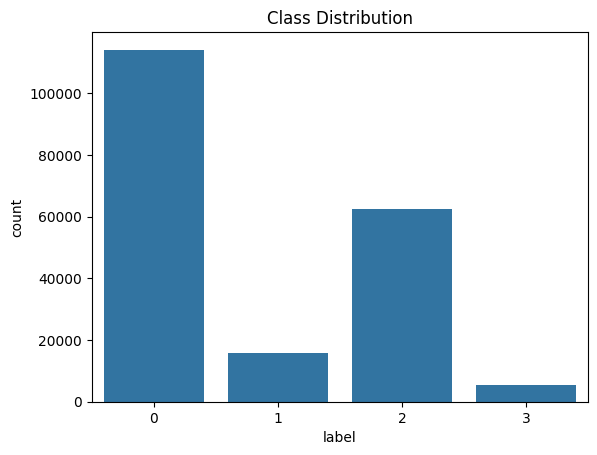

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sns.countplot(x='label', data=train_df)
plt.title("Class Distribution")
plt.show()

The dataset contains imbalanced class distributions, where some categories appear much less frequently than others. This was reflected in lower precision and recall for minority classes.

In [6]:
train_df.nunique()

created_date    197996
post_id             52
emoticon_1          36
emoticon_2          10
emoticon_3          16
upvote             122
downvote            62
if_1                57
if_2                81
race                 6
religion             8
gender               5
disability           2
comment         197842
label                4
dtype: int64

In [7]:
train_df['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [8]:
train_df['disability'].value_counts()

disability
False    195257
True       2743
Name: count, dtype: int64

In [9]:
train_df['race'].value_counts()

race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

In [10]:
train_df['comment'] = train_df['comment'].fillna("")
train_df[['race','religion','gender']] = train_df[['race','religion','gender']].fillna("unknown")
train_df['disability'] = train_df['disability'].astype(int)

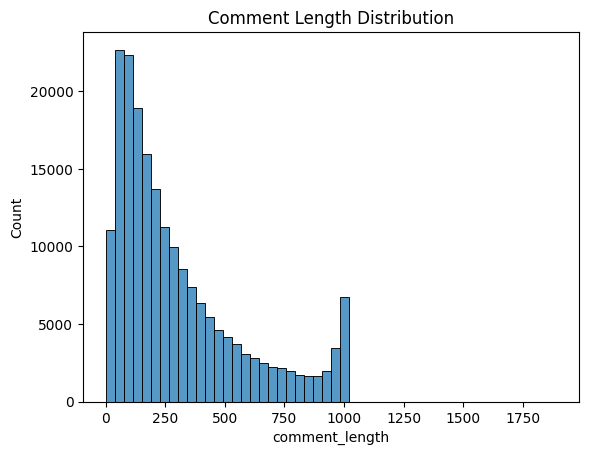

In [11]:
train_df['comment_length'] = train_df['comment'].apply(len)

sns.histplot(train_df['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.show()

1. The comment length distribution shows that most comments are relatively short, typically between 50 and 300 characters.
2. The distribution is right-skewed, with a small number of very long comments forming the tail.

In [12]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,comment_length
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,unknown,unknown,unknown,0,She might be a bright spot for a party keou on...,2,118
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,unknown,unknown,unknown,0,"Under Alaska law, a non-tribal member is not b...",0,644
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,unknown,unknown,unknown,0,in the future please spare me your strawman dr...,2,751
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,unknown,unknown,unknown,0,"PS: That should have been ""rot"" instead of ""co...",2,91
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,unknown,unknown,unknown,0,"Today, the confederate flag...tomorrow, the na...",2,254


In [13]:
text_col = 'comment'
num_cols = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3',
            'if_1','if_2','disability']
cat_cols = ['race','religion','gender']


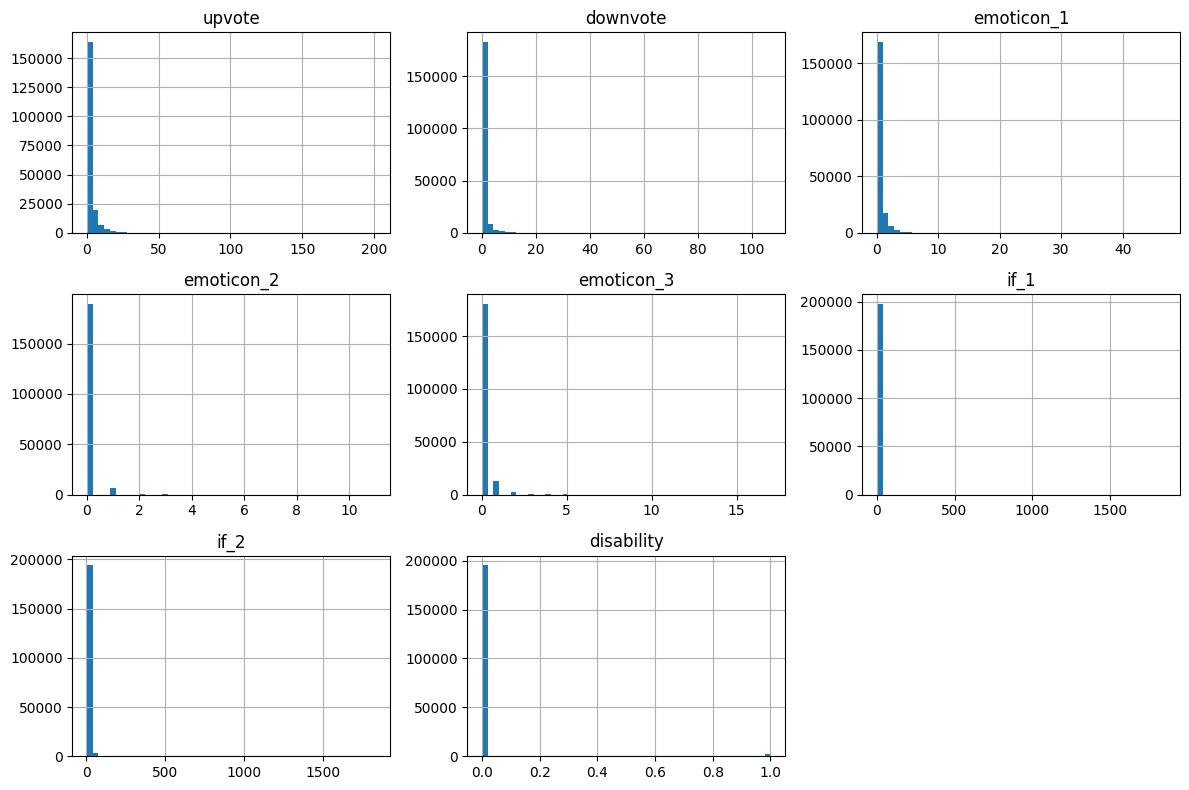

In [14]:
train_df[num_cols].hist(figsize=(12,8), bins=50)
plt.tight_layout()
plt.show()

1. The numeric features show strong right-skewed distributions with most observations concentrated near zero. 
2. Many of these variables represent sparse event counts such as emoticon usage. 
3. A small number of records contain large values, reflecting highly engaged comments with many interactions.

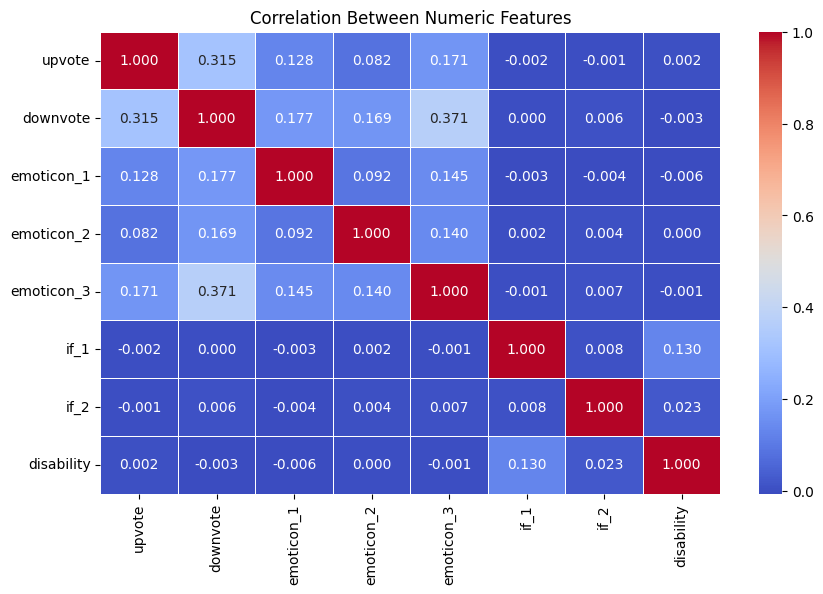

In [15]:
plt.figure(figsize=(10,6))  

sns.heatmap(
    train_df[num_cols].corr(),
    annot=True,
    fmt=".3f",        
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numeric Features")
plt.show()

1. Correlation analysis shows that most numeric features are weakly correlated with each other, indicating low redundancy among the variables.
2. The only moderate relationship observed is between upvotes and downvotes, which likely reflects overall user engagement.
3. Since no strong multicollinearity was detected, all numeric features were retained for model training.

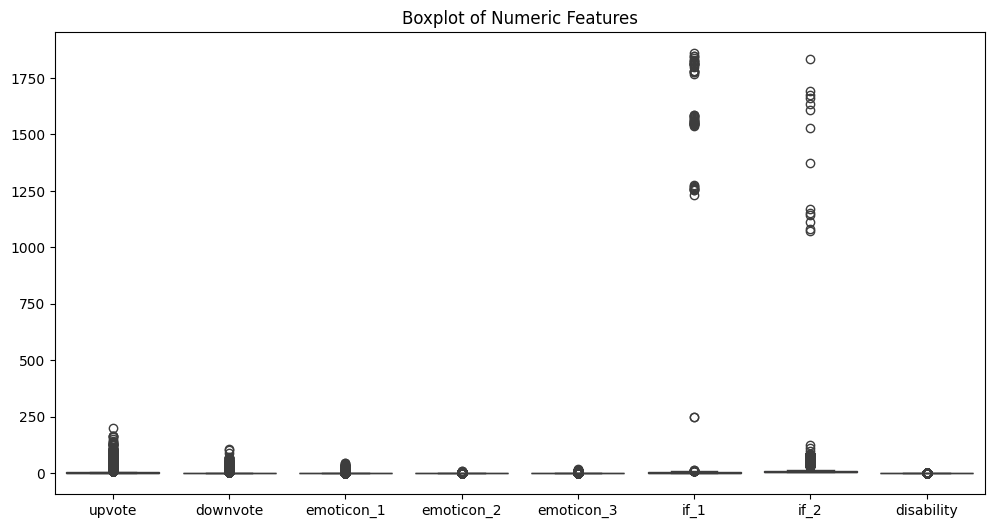

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_df[num_cols])
plt.title("Boxplot of Numeric Features")
plt.show()

In [17]:
Q1 = train_df[num_cols].quantile(0.25)
Q3 = train_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((train_df[num_cols] < (Q1 - 1.5 * IQR)) | 
            (train_df[num_cols] > (Q3 + 1.5 * IQR)))

print(outliers.sum())

upvote        17304
downvote      15173
emoticon_1    28922
emoticon_2     8109
emoticon_3    17165
if_1             85
if_2           3930
disability     2743
dtype: int64


1. Although several numeric features contain extreme values, these represent genuine user interactions rather than data errors.
2. Since the models used are robust to such variations, the outliers were retained.
3. Standardization was applied to numeric features to reduce the impact of extreme values during model training.

# FEATURE ENGINEERING & DATA PREPROCESSING

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,2),
            stop_words='english',
            sublinear_tf=True,
            min_df=3
        ), text_col),
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)


In [19]:
lgb_preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,2),
            stop_words='english',
            sublinear_tf=True,
            min_df=3
        ), text_col),
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [20]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['label','post_id','created_date'])
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

1. The post_id is an identifier rather than a meaningful predictive feature. Including it could cause the model to memorize specific discussion threads instead of learning general patterns in the text.
   
2. Temporal features extracted from created_date such as day, month, and weekday were tested but did not improve model performance. Since the task primarily depends on textual content rather than posting time, the timestamp feature was excluded from the final model.
   

# MODEL BUILDING

## Logistic Regression

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        C=1.0
    ))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_val)

print(X_train.shape)
print(X_val.shape)

print("Logistic Regression Results:")
print(classification_report(y_val, log_pred))


(158400, 13)
(39600, 13)
Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.68      0.85      0.75      3183
           2       0.88      0.86      0.87     12488
           3       0.50      0.76      0.60      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.85      0.80     39600
weighted avg       0.91      0.90      0.90     39600



Logistic Regression outperforms several other models by acheiving 0.80 macro F1 score, It was also computationally efficient compared to more complex models.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.5, 1.0, 1.5, 2.0]
}

grid = GridSearchCV(
    log_model,
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'classifier__C': 1.5}
0.7973369886795026


## Support Vector Machine(SVM) 

In [23]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LinearSVC(
        C=0.1,
        class_weight='balanced',
        max_iter=5000,
    ))
])

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_val)

print("Linear SVM Results:")
print(classification_report(y_val, svm_pred))

Linear SVM Results:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86     22835
           1       0.64      0.78      0.70      3183
           2       0.82      0.68      0.74     12488
           3       0.44      0.62      0.52      1094

    accuracy                           0.80     39600
   macro avg       0.68      0.74      0.70     39600
weighted avg       0.81      0.80      0.80     39600



Linear SVM achieved a macro F1 score of approximately 0.70, which is lower than Logistic Regression and LightGBM. This indicates that while SVM can perform well in high-dimensional spaces, in this dataset Logistic Regression provided better class separation.

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.01, 0.1, 0.5, 1, 2, 5]
}

grid_svm = GridSearchCV(
    svm_model,
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)

{'classifier__C': 0.1}
0.7042329919657074


## LightGBM

In [25]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline

lgb_pipeline = Pipeline([
    ('preprocessing', lgb_preprocessor),   
    ('classifier', lgb.LGBMClassifier(
        objective='multiclass',
        num_class=4,
        n_estimators=500,
        learning_rate=0.07,
        num_leaves=47,
        max_depth=-1,
        min_child_samples=15,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        force_col_wise=True,
        n_jobs=-1
    ))
])

lgb_pipeline.fit(X_train, y_train)

lgb_pred = lgb_pipeline.predict(X_val)

print("LightGBM Results:")
print(classification_report(y_val, lgb_pred))

[LightGBM] [Info] Total Bins 960528
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 30653
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
LightGBM Results:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.71      0.85      0.77      3183
           2       0.89      0.87      0.88     12488
           3       0.53      0.74      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.78      0.85      0.81     39600
weighted avg       0.92      0.91      0.91     39600



LightGBM also achieved a macro F1 score above 0.80, slightly improving recall for some minority classes. However, this improvement came at the cost of higher computational time, highlighting the trade-off between performance and efficiency.

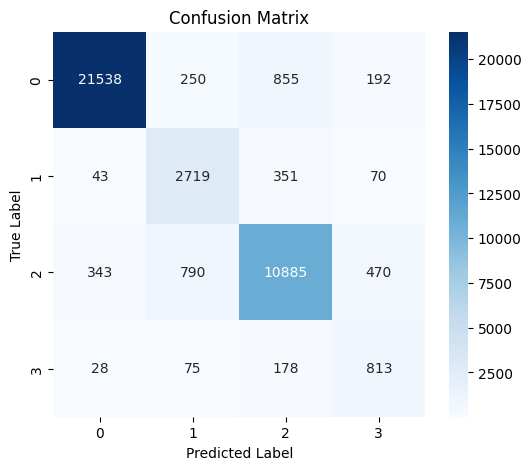

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, lgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# MODEL COMPARISON

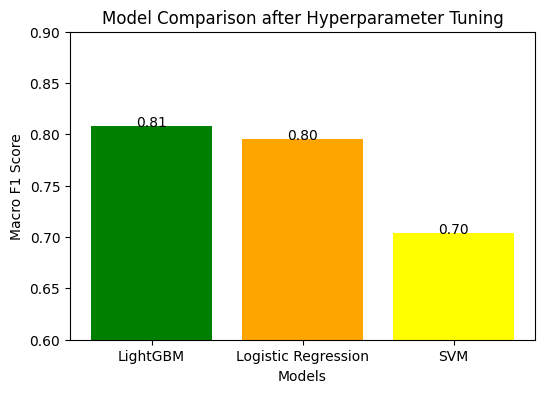

In [27]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

model_preds = {
    'LightGBM': lgb_pred,
    'Logistic Regression': log_pred,
    'SVM': svm_pred
}

models = []
macro_f1 = []

for name, pred in model_preds.items():
    models.append(name)
    score = f1_score(y_val, pred, average='macro')
    macro_f1.append(score)

plt.figure(figsize=(6,4))
plt.bar(models, macro_f1, color=['green', 'orange', 'yellow'])

for i in range(len(models)):
    plt.text(i, macro_f1[i], f"{macro_f1[i]:.2f}", ha='center', fontsize=10)

plt.xlabel("Models")
plt.ylabel("Macro F1 Score")   
plt.title("Model Comparison after Hyperparameter Tuning")
plt.ylim(0.60, 0.90)

plt.show()

**Model Comparison after hyper parameter tuning**:

1. LightGBM - Validation Macro_F1 : 0.81
2. Logistic Regression  - Validation Macro_F1 : 0.80
3. SVM - Validation Macro_F1 : 0.70

**BEST MODEL : LightGBM**

# SUBMISSION

In [28]:
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")


test_df = test_df.drop(columns=['post_id', 'created_date'], errors='ignore')

test_df['comment'] = test_df['comment'].fillna("")
test_df[['race','religion','gender']] = \
    test_df[['race','religion','gender']].fillna("unknown")
test_df['disability'] = test_df['disability'].astype(int)

test_predictions = lgb_pipeline.predict(test_df)


In [29]:
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
sample_sub.head()


,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [30]:
sample_sub['label'] = test_predictions
sample_sub.to_csv("submission.csv", index=False)